In [2]:
# =============================================================================
# TEXT FEATURE ENGINEERING ASSIGNMENT
# =============================================================================

# -----------------------------------------------------------------------------
# SECTION 0: IMPORTS AND SETUP
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import re
import string
from collections import Counter

# NLP Libraries
import nltk #uv pip install nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn for feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

print("All libraries imported successfully!")


All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhnam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhnam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bhnam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhnam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Section 1: Data Collection

In [8]:
# =============================================================================
# OPTION B: SIMULATED DATASET (For demonstration without scraping)
# =============================================================================

def create_sample_dataset():
    """
    Create a realistic sample dataset mimicking product reviews.
    Use this if scraping is not possible.
    """
    
    positive_reviews = [
        "This product is absolutely amazing! Best purchase I have ever made. The quality is outstanding.",
        "Excellent value for money. Fast delivery and the product works perfectly as described.",
        "I am very happy with this purchase. The product exceeded my expectations completely.",
        "Great quality product. Would definitely recommend to friends and family.",
        "Amazing product with excellent features. Worth every penny spent on it.",
        "Very satisfied with this purchase. The product is exactly what I needed.",
        "Outstanding quality and performance. This is the best product in this price range.",
        "Highly recommend this product. It has made my life so much easier.",
        "Fantastic product with great build quality. Very impressed with the purchase.",
        "Love this product! It works flawlessly and looks beautiful too.",
        "Best product I have bought online. Super fast delivery and great packaging.",
        "Excellent product quality. The company has done a wonderful job.",
        "Very good product. Easy to use and works exactly as advertised.",
        "Brilliant product at an affordable price. Highly satisfied customer here.",
        "This product is a game changer. Absolutely love it and use it daily.",
        "Premium quality product. The attention to detail is impressive.",
        "Wonderful purchase. The product arrived on time and works great.",
        "Amazing quality for this price. Could not be happier with my decision.",
        "Five stars are not enough for this product. Absolutely phenomenal.",
        "Great product with excellent customer service. Will buy again.",
        "This product has transformed my daily routine. Highly recommended.",
        "Superb quality and fast shipping. Very pleased with the purchase.",
        "Incredible product value. Better than expected in every way.",
        "Perfect product for my needs. Works exactly as described.",
        "Top notch quality. This product is worth every rupee.",
        "Extremely happy with this purchase. The product is flawless.",
        "Best in class product. Outstanding performance and durability.",
        "Wonderful product experience. Smooth ordering and fast delivery.",
        "Excellent build quality. This product feels premium and sturdy.",
        "Highly impressed with this product. Exceeded all expectations.",
        "Great product features and easy setup. Very user friendly.",
        "This product is exactly what I was looking for. Perfect match.",
        "Superior quality product. Definitely worth the investment.",
        "Amazing product performance. Works better than expensive alternatives.",
        "Very good value for money. Product quality is top tier.",
        "Fantastic purchase decision. This product is a must have.",
        "Excellent product with great features. Highly satisfied.",
        "Outstanding customer experience. Product is simply superb.",
        "Love everything about this product. Quality packaging too.",
        "Best purchase of the year. This product is incredible.",
        "Highly recommended product. Great quality and performance.",
        "Amazing build quality. This product will last for years.",
        "Perfect product at perfect price. Could not ask for more.",
        "Exceptional product quality. Very happy with my purchase.",
        "Great value product. Works perfectly and looks stylish.",
        "This product deserves all the praise. Absolutely fantastic.",
        "Wonderful product experience from start to finish.",
        "Superior performance product. Beats the competition easily.",
        "Excellent purchase. Product arrived quickly and works great.",
        "Five star product all the way. Highly recommend to everyone."
    ]
    
    negative_reviews = [
        "Very disappointed with this product. Poor quality and does not work properly.",
        "Waste of money. The product stopped working after just two days.",
        "Terrible product quality. Would not recommend to anyone at all.",
        "Product arrived damaged and customer service was unhelpful.",
        "Not worth the price. Product quality is very poor and cheap.",
        "Extremely disappointed. Product does not match the description at all.",
        "Worst purchase ever. The product is completely useless and broken.",
        "Very bad experience with this product. Total waste of money.",
        "Product quality is horrible. Broke within the first week.",
        "Do not buy this product. It is of very low quality.",
        "Regret buying this. The product is not as shown in pictures.",
        "Poor quality material used. Product feels cheap and flimsy.",
        "Complete waste of money. Product does not work as advertised.",
        "Very unhappy with this purchase. The product is defective.",
        "Horrible product experience. Customer support is useless too.",
        "Product quality is substandard. Not recommended at all.",
        "Disappointed with the quality. Expected much better for the price.",
        "Bad product. Stopped functioning properly within days.",
        "Terrible purchase. The product is nothing like described.",
        "Would give zero stars if possible. Product is garbage.",
        "Extremely poor quality. Do not waste your money on this.",
        "Product is a complete scam. Does not work at all.",
        "Very bad quality product. Feels like a cheap knockoff.",
        "Worst product I have ever bought. Total disappointment.",
        "Product broke immediately. No response from seller.",
        "Highly disappointed. Quality is nowhere near expectations.",
        "Do not recommend this product. Save your money.",
        "Pathetic product quality. Waste of hard earned money.",
        "Product is faulty right out of the box. Very frustrating.",
        "Terrible experience. Product is defective and useless.",
        "Not satisfied at all. Product quality is very poor.",
        "Bad purchase decision. This product is worthless.",
        "Product stopped working after few uses. Very disappointed.",
        "Horrible quality. The product fell apart quickly.",
        "Waste of time and money. Product does not work.",
        "Very poor construction. Product broke within a month.",
        "Disappointed customer here. Product is not worth it.",
        "Low quality product sold at high price. Avoid this.",
        "Product is falsely advertised. Nothing like shown.",
        "Terrible product. Would not recommend to my worst enemy.",
        "Complete disaster of a product. Stay away from this.",
        "Product arrived broken. Return process is nightmare.",
        "Subpar quality. Expected much better from this brand.",
        "Very bad experience. Product malfunctioned quickly.",
        "Do not trust the reviews. Product is terrible quality.",
        "Disappointed beyond words. This product is useless.",
        "Poor quality control. Product has many defects.",
        "Not worth even half the price. Terrible product.",
        "Worst online shopping experience. Product is junk.",
        "Avoid this product. It is poorly made and unreliable."
    ]
    
    # Combine and create labels
    all_reviews = positive_reviews + negative_reviews
    labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)  # 1=positive, 0=negative
    ratings = ['5'] * 25 + ['4'] * 25 + ['1'] * 25 + ['2'] * 25
    
    # Create DataFrame
    df = pd.DataFrame({
        'review_text': all_reviews,
        'rating': ratings,
        'sentiment': labels
    })
    
    # Shuffle the data
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

# Create and save the dataset
df = create_sample_dataset()
df.to_csv('product_reviews.csv', index=False)
print(f"Dataset created with {len(df)} reviews")
print(f"Positive reviews: {sum(df['sentiment'] == 1)}")
print(f"Negative reviews: {sum(df['sentiment'] == 0)}")
df.head(10)


Dataset created with 100 reviews
Positive reviews: 50
Negative reviews: 50


,review_text,rating,sentiment
0,Horrible quality. The product fell apart quickly.,2,0
1,Product arrived damaged and customer service w...,1,0
2,Extremely poor quality. Do not waste your mone...,1,0
3,This product deserves all the praise. Absolute...,4,1
4,Great value product. Works perfectly and looks...,4,1
5,Best purchase of the year. This product is inc...,4,1
6,Incredible product value. Better than expected...,5,1
7,Not satisfied at all. Product quality is very ...,2,0
8,Best product I have bought online. Super fast ...,5,1
9,This product is absolutely amazing! Best purch...,5,1


Section 2: Text Preprocessing (Task 1)

In [9]:
# =============================================================================
# TASK 1: TEXT PREPROCESSING
# =============================================================================

class TextPreprocessor:
    """
    A comprehensive text preprocessing class for NLP tasks.
    """
    
    def __init__(self, remove_stopwords=True, apply_lemmatization=True):
        self.remove_stopwords = remove_stopwords
        self.apply_lemmatization = apply_lemmatization
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
    def to_lowercase(self, text):
        """Convert text to lowercase"""
        return text.lower()
    
    def remove_punctuation(self, text):
        """Remove all punctuation from text"""
        return text.translate(str.maketrans('', '', string.punctuation))
    
    def remove_numbers(self, text):
        """Remove numbers from text"""
        return re.sub(r'\d+', '', text)
    
    def remove_extra_whitespace(self, text):
        """Remove extra whitespace"""
        return ' '.join(text.split())
    
    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)
    
    def remove_stopwords_from_tokens(self, tokens):
        """Remove stopwords from token list"""
        return [token for token in tokens if token not in self.stop_words]
    
    def lemmatize_tokens(self, tokens):
        """Apply lemmatization to tokens"""
        return [self.lemmatizer.lemmatize(token) for token in tokens]
    
    def preprocess(self, text):
        """
        Complete preprocessing pipeline
        
        Steps:
        1. Convert to lowercase
        2. Remove punctuation
        3. Remove numbers
        4. Remove extra whitespace
        5. Tokenization
        6. Remove stopwords (optional)
        7. Lemmatization (optional)
        """
        # Step 1: Lowercase
        text = self.to_lowercase(text)
        
        # Step 2: Remove punctuation
        text = self.remove_punctuation(text)
        
        # Step 3: Remove numbers
        text = self.remove_numbers(text)
        
        # Step 4: Remove extra whitespace
        text = self.remove_extra_whitespace(text)
        
        # Step 5: Tokenization
        tokens = self.tokenize(text)
        
        # Step 6: Remove stopwords (optional)
        if self.remove_stopwords:
            tokens = self.remove_stopwords_from_tokens(tokens)
        
        # Step 7: Lemmatization (optional)
        if self.apply_lemmatization:
            tokens = self.lemmatize_tokens(tokens)
        
        return tokens
    
    def preprocess_to_string(self, text):
        """Return preprocessed text as a single string"""
        tokens = self.preprocess(text)
        return ' '.join(tokens)


# Initialize preprocessor
preprocessor = TextPreprocessor(remove_stopwords=True, apply_lemmatization=True)

# Apply preprocessing to all reviews
df['processed_text'] = df['review_text'].apply(preprocessor.preprocess_to_string)
df['tokens'] = df['review_text'].apply(preprocessor.preprocess)

# Display preprocessing results
print("="*80)
print("PREPROCESSING EXAMPLES")
print("="*80)

for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df['review_text'].iloc[i]}")
    print(f"Processed: {df['processed_text'].iloc[i]}")
    print(f"Tokens: {df['tokens'].iloc[i]}")


PREPROCESSING EXAMPLES

--- Example 1 ---
Original: Horrible quality. The product fell apart quickly.
Processed: horrible quality product fell apart quickly
Tokens: ['horrible', 'quality', 'product', 'fell', 'apart', 'quickly']

--- Example 2 ---
Original: Product arrived damaged and customer service was unhelpful.
Processed: product arrived damaged customer service unhelpful
Tokens: ['product', 'arrived', 'damaged', 'customer', 'service', 'unhelpful']

--- Example 3 ---
Original: Extremely poor quality. Do not waste your money on this.
Processed: extremely poor quality waste money
Tokens: ['extremely', 'poor', 'quality', 'waste', 'money']


Section 3: Vocabulary Creation (Task 2)

VOCABULARY ANALYSIS

Total Vocabulary Size: 226 unique words
Total Word Count: 603 words

----------------------------------------
TOP 30 MOST FREQUENT WORDS
----------------------------------------
 1. product         :   94 occurrences
 2. quality         :   34 occurrences
 3. purchase        :   15 occurrences
 4. work            :   12 occurrences
 5. great           :   10 occurrences
 6. money           :    9 occurrences
 7. price           :    8 occurrences
 8. highly          :    8 occurrences
 9. experience      :    8 occurrences
10. poor            :    7 occurrences
11. excellent       :    7 occurrences
12. disappointed    :    7 occurrences
13. customer        :    6 occurrences
14. waste           :    6 occurrences
15. worth           :    6 occurrences
16. recommend       :    6 occurrences
17. terrible        :    6 occurrences
18. best            :    5 occurrences
19. amazing         :    5 occurrences
20. performance     :    5 occurrences
21. bad             :

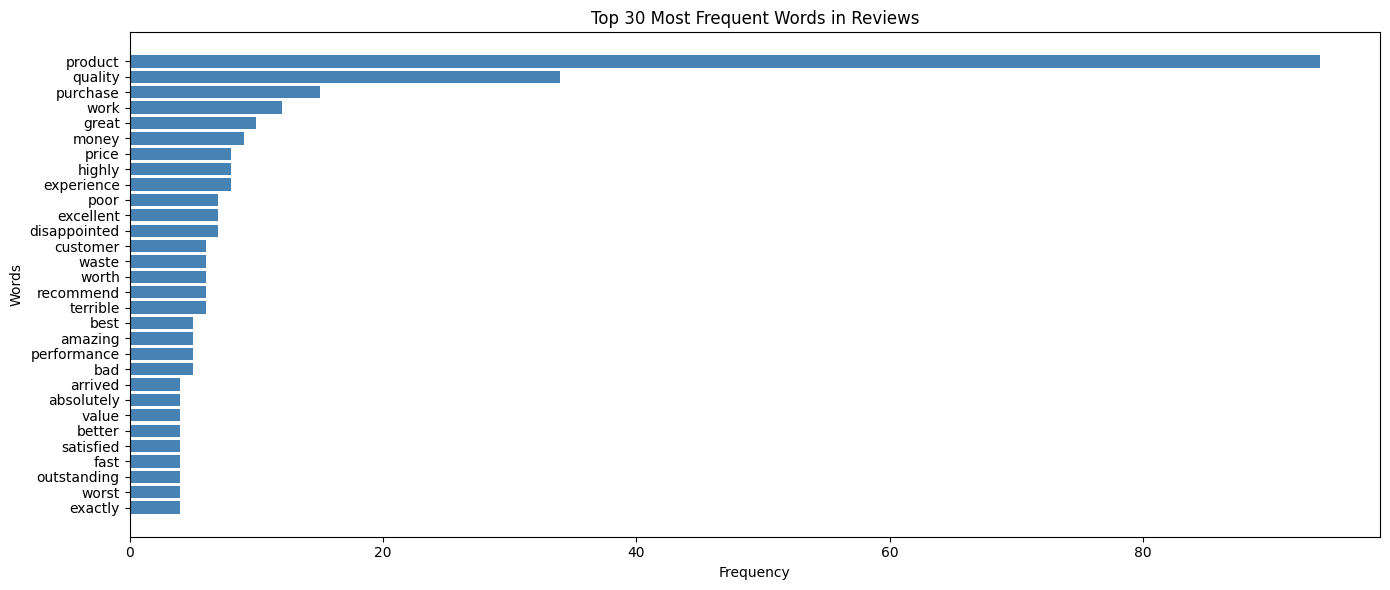


----------------------------------------
WORD FREQUENCY DISTRIBUTION
----------------------------------------
Words appearing only once: 129
Words appearing 2-5 times: 80
Words appearing 6-10 times: 13
Words appearing 10+ times: 4


In [10]:
# =============================================================================
# TASK 2: VOCABULARY CREATION
# =============================================================================

def build_vocabulary(corpus):
    """
    Build vocabulary manually from corpus
    
    Parameters:
    - corpus: List of tokenized documents
    
    Returns:
    - vocabulary: Dictionary mapping words to indices
    - word_counts: Counter object with word frequencies
    """
    word_counts = Counter()
    
    for tokens in corpus:
        word_counts.update(tokens)
    
    # Create vocabulary (word to index mapping)
    vocabulary = {word: idx for idx, (word, count) in enumerate(word_counts.most_common())}
    
    return vocabulary, word_counts


# Build vocabulary from preprocessed tokens
vocabulary, word_counts = build_vocabulary(df['tokens'].tolist())

print("="*80)
print("VOCABULARY ANALYSIS")
print("="*80)

print(f"\nTotal Vocabulary Size: {len(vocabulary)} unique words")
print(f"Total Word Count: {sum(word_counts.values())} words")

# Top 30 most frequent words
print("\n" + "-"*40)
print("TOP 30 MOST FREQUENT WORDS")
print("-"*40)

top_30 = word_counts.most_common(30)
for i, (word, count) in enumerate(top_30, 1):
    print(f"{i:2}. {word:15} : {count:4} occurrences")

# Visualize top words
plt.figure(figsize=(14, 6))
words, counts = zip(*top_30)
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 30 Most Frequent Words in Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_words_frequency.png', dpi=150)
plt.show()

# Word frequency distribution
print("\n" + "-"*40)
print("WORD FREQUENCY DISTRIBUTION")
print("-"*40)

freq_dist = {}
for word, count in word_counts.items():
    if count not in freq_dist:
        freq_dist[count] = 0
    freq_dist[count] += 1

print(f"Words appearing only once: {freq_dist.get(1, 0)}")
print(f"Words appearing 2-5 times: {sum(freq_dist.get(i, 0) for i in range(2, 6))}")
print(f"Words appearing 6-10 times: {sum(freq_dist.get(i, 0) for i in range(6, 11))}")
print(f"Words appearing 10+ times: {sum(v for k, v in freq_dist.items() if k > 10)}")


Section 4: Feature Engineering (Task 3)

In [11]:
# =============================================================================
# TASK 3: FEATURE ENGINEERING
# =============================================================================

# -----------------------------------------------------------------------------
# 3.1 ONE HOT ENCODING (Document-level)
# -----------------------------------------------------------------------------

def one_hot_encode(documents, vocabulary):
    """
    Create One Hot Encoding for documents
    
    Each document is represented as a binary vector indicating
    presence (1) or absence (0) of each vocabulary word.
    """
    num_docs = len(documents)
    vocab_size = len(vocabulary)
    
    # Initialize matrix with zeros
    ohe_matrix = np.zeros((num_docs, vocab_size), dtype=int)
    
    for doc_idx, tokens in enumerate(documents):
        for token in tokens:
            if token in vocabulary:
                word_idx = vocabulary[token]
                ohe_matrix[doc_idx, word_idx] = 1  # Binary: just 1 for presence
    
    return ohe_matrix

# Create One Hot Encoding
ohe_matrix = one_hot_encode(df['tokens'].tolist(), vocabulary)

print("="*80)
print("ONE HOT ENCODING")
print("="*80)
print(f"\nMatrix Shape: {ohe_matrix.shape}")
print(f"  - {ohe_matrix.shape[0]} documents")
print(f"  - {ohe_matrix.shape[1]} features (vocabulary size)")

# Show sample
print("\nSample OHE Vector (first document, first 20 features):")
print(ohe_matrix[0, :20])

print(f"\nDocument 1 has {ohe_matrix[0].sum()} unique words from vocabulary")


# -----------------------------------------------------------------------------
# 3.2 BAG OF WORDS (CountVectorizer)
# -----------------------------------------------------------------------------

# Initialize CountVectorizer
count_vectorizer = CountVectorizer(
    max_features=1000,      # Limit to top 1000 words
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.95             # Ignore words appearing in >95% of documents
)

# Fit and transform
bow_matrix = count_vectorizer.fit_transform(df['processed_text'])
bow_feature_names = count_vectorizer.get_feature_names_out()

print("\n" + "="*80)
print("BAG OF WORDS (CountVectorizer)")
print("="*80)
print(f"\nMatrix Shape: {bow_matrix.shape}")
print(f"  - {bow_matrix.shape[0]} documents")
print(f"  - {bow_matrix.shape[1]} features")

print(f"\nVocabulary Size: {len(bow_feature_names)}")
print(f"First 20 words in vocabulary: {list(bow_feature_names[:20])}")

# Show sample document representation
print("\nSample BoW representation (Document 1):")
doc1_bow = bow_matrix[0].toarray()[0]
non_zero_indices = np.where(doc1_bow > 0)[0]
print("Word frequencies in document 1:")
for idx in non_zero_indices[:10]:
    print(f"  '{bow_feature_names[idx]}': {doc1_bow[idx]}")


# -----------------------------------------------------------------------------
# 3.3 TF-IDF (TfidfVectorizer)
# -----------------------------------------------------------------------------

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=2,
    max_df=0.95,
    norm='l2'               # L2 normalization
)

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("\n" + "="*80)
print("TF-IDF (TfidfVectorizer)")
print("="*80)
print(f"\nMatrix Shape: {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} documents")
print(f"  - {tfidf_matrix.shape[1]} features")

# Show sample document representation
print("\nSample TF-IDF representation (Document 1):")
doc1_tfidf = tfidf_matrix[0].toarray()[0]
non_zero_indices = np.where(doc1_tfidf > 0)[0]
sorted_indices = non_zero_indices[np.argsort(doc1_tfidf[non_zero_indices])[::-1]]

print("Top 10 TF-IDF weighted words in document 1:")
for idx in sorted_indices[:10]:
    print(f"  '{tfidf_feature_names[idx]}': {doc1_tfidf[idx]:.4f}")

# Get overall important words by TF-IDF
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_tfidf_indices = mean_tfidf.argsort()[::-1][:20]

print("\nTop 20 words by average TF-IDF score across all documents:")
for idx in top_tfidf_indices:
    print(f"  '{tfidf_feature_names[idx]}': {mean_tfidf[idx]:.4f}")


ONE HOT ENCODING

Matrix Shape: (100, 226)
  - 100 documents
  - 226 features (vocabulary size)

Sample OHE Vector (first document, first 20 features):
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Document 1 has 6 unique words from vocabulary

BAG OF WORDS (CountVectorizer)

Matrix Shape: (100, 97)
  - 100 documents
  - 97 features

Vocabulary Size: 97
First 20 words in vocabulary: ['absolutely', 'advertised', 'amazing', 'arrived', 'avoid', 'bad', 'best', 'better', 'bought', 'broke', 'broken', 'build', 'buy', 'cheap', 'complete', 'completely', 'could', 'customer', 'daily', 'day']

Sample BoW representation (Document 1):
Word frequencies in document 1:
  'horrible': 1
  'product': 1
  'quality': 1
  'quickly': 1

TF-IDF (TfidfVectorizer)

Matrix Shape: (100, 97)
  - 100 documents
  - 97 features

Sample TF-IDF representation (Document 1):
Top 10 TF-IDF weighted words in document 1:
  'quickly': 0.6593
  'horrible': 0.6593
  'quality': 0.3212
  'product': 0.1655

Top 20 words by average TF

Section 5: Comparison Analysis (Task 4)

In [12]:
# =============================================================================
# TASK 4: COMPARISON ANALYSIS
# =============================================================================

print("="*80)
print("COMPARISON: ONE HOT ENCODING vs BAG OF WORDS vs TF-IDF")
print("="*80)

# Create comparison table
comparison_data = {
    'Aspect': [
        'Matrix Type',
        'Value Range',
        'What it Captures',
        'Word Frequency',
        'Word Importance',
        'Document Length Normalization',
        'Sparsity',
        'Computational Cost',
        'Information Loss',
        'Best Use Case'
    ],
    'One Hot Encoding': [
        'Binary (0 or 1)',
        '[0, 1]',
        'Word presence only',
        'No',
        'All words equal',
        'No',
        'Very High',
        'Low',
        'High (no frequency)',
        'Simple presence detection'
    ],
    'Bag of Words': [
        'Integer counts',
        '[0, ∞)',
        'Word frequency',
        'Yes',
        'All words equal',
        'No',
        'High',
        'Medium',
        'Medium (no importance)',
        'Frequency-based analysis'
    ],
    'TF-IDF': [
        'Float weights',
        '[0, 1]',
        'Word importance',
        'Yes (TF)',
        'Weighted by rarity (IDF)',
        'Yes (L2 norm)',
        'High',
        'Medium-High',
        'Low',
        'Document classification, search'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Detailed analysis
print("\n" + "-"*80)
print("DETAILED ANALYSIS: WHY TF-IDF DOWN-WEIGHTS COMMON WORDS")
print("-"*80)

print("""
TF-IDF (Term Frequency - Inverse Document Frequency) Formula:
    TF-IDF(t, d) = TF(t, d) × IDF(t)

Where:
    TF(t, d)  = (Count of term t in document d) / (Total terms in document d)
    IDF(t)    = log(Total documents / Documents containing term t)

WHY COMMON WORDS GET LOWER WEIGHT:
----------------------------------
1. IDF Penalizes Ubiquity:
   - If a word appears in ALL documents, IDF = log(N/N) = log(1) = 0
   - This makes TF-IDF = TF × 0 = 0 for universal words

2. Example Calculation:
   - Word "product" appears in 90 out of 100 documents
   - IDF("product") = log(100/90) = 0.046 (very low)
   
   - Word "phenomenal" appears in 5 out of 100 documents
   - IDF("phenomenal") = log(100/5) = 1.30 (much higher)

3. Intuition:
   - Words appearing everywhere (the, is, product) don't help distinguish documents
   - Rare words (phenomenal, garbage, flawless) are more discriminative
   - TF-IDF automatically identifies these distinctive words
""")

# Demonstrate with actual data
print("\n" + "-"*40)
print("EXAMPLE FROM OUR DATA")
print("-"*40)

# Calculate document frequency for some words
sample_words = ['product', 'quality', 'excellent', 'terrible', 'phenomenal', 'garbage']

for word in sample_words:
    if word in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[word]
        doc_freq = (tfidf_matrix[:, idx].toarray() > 0).sum()
        avg_tfidf = tfidf_matrix[:, idx].mean()
        print(f"'{word}': appears in {doc_freq} docs, avg TF-IDF = {avg_tfidf:.4f}")


COMPARISON: ONE HOT ENCODING vs BAG OF WORDS vs TF-IDF


                       Aspect          One Hot Encoding             Bag of Words                          TF-IDF
                  Matrix Type           Binary (0 or 1)           Integer counts                   Float weights
                  Value Range                    [0, 1]                   [0, ∞)                          [0, 1]
             What it Captures        Word presence only           Word frequency                 Word importance
               Word Frequency                        No                      Yes                        Yes (TF)
              Word Importance           All words equal          All words equal        Weighted by rarity (IDF)
Document Length Normalization                        No                       No                   Yes (L2 norm)
                     Sparsity                 Very High                     High                            High
           Computational Cost          

Section 6: Sparse Matrix Analysis (Task 5)

SPARSE MATRIX ANALYSIS

ONE HOT ENCODING
----------------------------------------
Shape: (100, 226)
Total elements: 22,600
Non-zero elements: 602
Zero elements: 21,998
Sparsity: 97.34%
Density: 2.66%
Dense memory (approx): 0.17 MB
Sparse memory (approx): 0.1724 MB
Memory savings: 0.0%

BAG OF WORDS
----------------------------------------
Shape: (100, 97)
Total elements: 9,700
Non-zero elements: 473
Zero elements: 9,227
Sparsity: 95.12%
Density: 4.88%
Dense memory (approx): 0.07 MB
Sparse memory (approx): 0.0058 MB
Memory savings: 92.2%

TF-IDF
----------------------------------------
Shape: (100, 97)
Total elements: 9,700
Non-zero elements: 473
Zero elements: 9,227
Sparsity: 95.12%
Density: 4.88%
Dense memory (approx): 0.07 MB
Sparse memory (approx): 0.0058 MB
Memory savings: 92.2%

--------------------------------------------------------------------------------
SPARSITY COMPARISON VISUALIZATION
--------------------------------------------------------------------------------


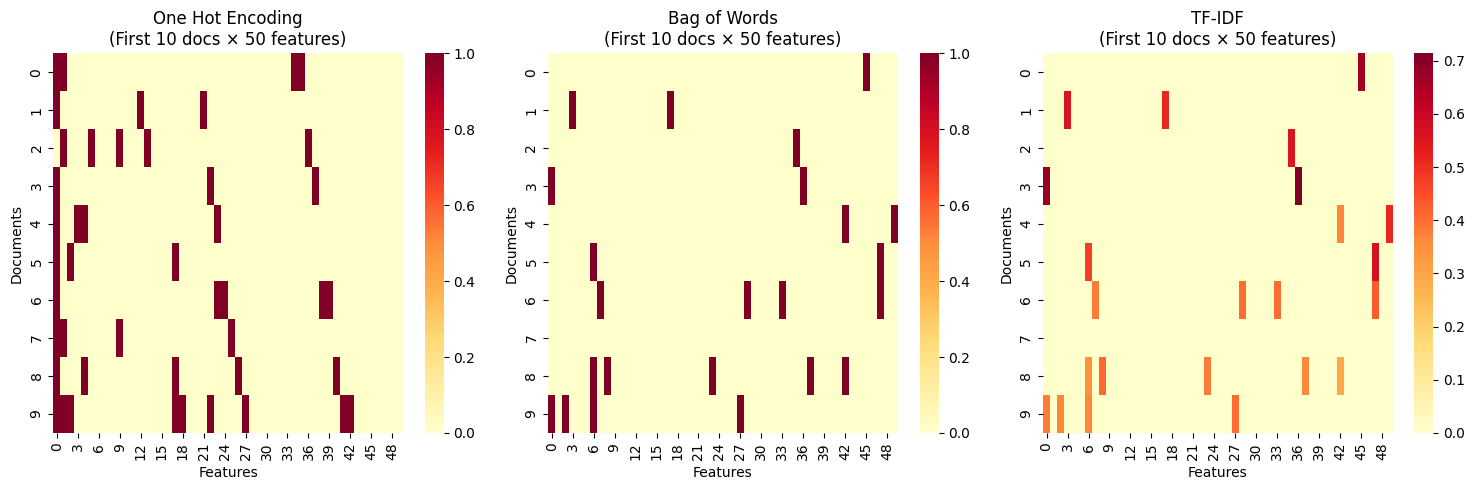


--------------------------------------------------------------------------------
WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS
--------------------------------------------------------------------------------

CHALLENGES WITH SPARSE MATRICES AT SCALE:

1. MEMORY INEFFICIENCY (Dense Storage):
   - With 1 million documents and 100,000 vocabulary
   - Dense matrix: 1M × 100K × 8 bytes = 800 GB
   - Most values are zeros, wasting memory

2. COMPUTATIONAL OVERHEAD:
   - Matrix operations process many zero values
   - Dot products include millions of 0×0 = 0 operations
   - Training ML models becomes slow

3. CURSE OF DIMENSIONALITY:
   - High-dimensional sparse space makes distance metrics unreliable
   - "Nearest neighbor" becomes meaningless when all points are equidistant
   - Models struggle to find patterns in sparse data

4. STORAGE AND I/O:
   - Large sparse matrices are slow to save/load
   - Network transfer becomes bottleneck in distributed systems

5. REAL-WORLD SOL

In [13]:
# =============================================================================
# TASK 5: SPARSE MATRIX ANALYSIS
# =============================================================================

print("="*80)
print("SPARSE MATRIX ANALYSIS")
print("="*80)

def analyze_sparsity(matrix, name):
    """Analyze sparsity of a matrix"""
    
    if hasattr(matrix, 'toarray'):
        # Sparse matrix
        total_elements = matrix.shape[0] * matrix.shape[1]
        non_zero = matrix.nnz
        zeros = total_elements - non_zero
        sparsity = (zeros / total_elements) * 100
        
        # Memory comparison
        dense_memory = total_elements * 8 / (1024 * 1024)  # 8 bytes per float64
        sparse_memory = (non_zero * 12 + matrix.shape[0] * 4) / (1024 * 1024)  # approximate CSR
    else:
        # Dense matrix
        total_elements = matrix.size
        zeros = np.sum(matrix == 0)
        non_zero = total_elements - zeros
        sparsity = (zeros / total_elements) * 100
        dense_memory = total_elements * 8 / (1024 * 1024)
        sparse_memory = dense_memory
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"Shape: {matrix.shape}")
    print(f"Total elements: {total_elements:,}")
    print(f"Non-zero elements: {non_zero:,}")
    print(f"Zero elements: {zeros:,}")
    print(f"Sparsity: {sparsity:.2f}%")
    print(f"Density: {100-sparsity:.2f}%")
    print(f"Dense memory (approx): {dense_memory:.2f} MB")
    print(f"Sparse memory (approx): {sparse_memory:.4f} MB")
    print(f"Memory savings: {((dense_memory - sparse_memory) / dense_memory * 100):.1f}%")
    
    return sparsity

# Analyze all matrices
sparsity_ohe = analyze_sparsity(ohe_matrix, "ONE HOT ENCODING")
sparsity_bow = analyze_sparsity(bow_matrix, "BAG OF WORDS")
sparsity_tfidf = analyze_sparsity(tfidf_matrix, "TF-IDF")

# Visualization
print("\n" + "-"*80)
print("SPARSITY COMPARISON VISUALIZATION")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

matrices = [
    (ohe_matrix[:10, :50], 'One Hot Encoding'),
    (bow_matrix[:10, :50].toarray(), 'Bag of Words'),
    (tfidf_matrix[:10, :50].toarray(), 'TF-IDF')
]

for ax, (matrix, title) in zip(axes, matrices):
    if hasattr(matrix, 'toarray'):
        matrix = matrix.toarray()
    sns.heatmap(matrix, ax=ax, cmap='YlOrRd', cbar=True)
    ax.set_title(f'{title}\n(First 10 docs × 50 features)')
    ax.set_xlabel('Features')
    ax.set_ylabel('Documents')

plt.tight_layout()
plt.savefig('sparsity_visualization.png', dpi=150)
plt.show()

# Why sparse matrices are problematic at scale
print("\n" + "-"*80)
print("WHY SPARSE MATRICES ARE INEFFICIENT FOR LARGE-SCALE SYSTEMS")
print("-"*80)

print("""
CHALLENGES WITH SPARSE MATRICES AT SCALE:

1. MEMORY INEFFICIENCY (Dense Storage):
   - With 1 million documents and 100,000 vocabulary
   - Dense matrix: 1M × 100K × 8 bytes = 800 GB
   - Most values are zeros, wasting memory
   
2. COMPUTATIONAL OVERHEAD:
   - Matrix operations process many zero values
   - Dot products include millions of 0×0 = 0 operations
   - Training ML models becomes slow

3. CURSE OF DIMENSIONALITY:
   - High-dimensional sparse space makes distance metrics unreliable
   - "Nearest neighbor" becomes meaningless when all points are equidistant
   - Models struggle to find patterns in sparse data

4. STORAGE AND I/O:
   - Large sparse matrices are slow to save/load
   - Network transfer becomes bottleneck in distributed systems

5. REAL-WORLD SOLUTIONS:
   - Dimensionality reduction (PCA, SVD, LSA)
   - Word embeddings (Word2Vec, GloVe, FastText)
   - Transformer models (BERT, GPT) with dense representations
   - Feature selection and vocabulary pruning
   - Hashing techniques (Feature Hashing)

EXAMPLE SCALING:
- Twitter processes ~500M tweets/day
- Vocabulary size: ~1M words
- BoW matrix per day: 500M × 1M = 500 trillion cells
- This is computationally infeasible without dimensionality reduction
""")


Section 7: Real-world Questions (Task 6)

In [14]:
# =============================================================================
# TASK 6: REAL-WORLD QUESTIONS
# =============================================================================

print("="*80)
print("REAL-WORLD NLP QUESTIONS AND ANSWERS")
print("="*80)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 1: Why does Bag of Words fail to understand semantic meaning?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Bag of Words treats each word as an independent feature, completely ignoring:

1. SYNONYMS (Same meaning, different words):
   - "happy" and "joyful" are treated as completely different features
   - "purchase" and "buy" have zero similarity in BoW
   - Documents using synonyms appear unrelated

2. WORD ORDER (Context and grammar):
   - "Dog bites man" and "Man bites dog" have IDENTICAL BoW representations
   - "Not good" loses negation context when words are separated
   - Questions vs statements look the same

3. POLYSEMY (Same word, different meanings):
   - "bank" (river bank vs financial bank) treated identically
   - "apple" (fruit vs company) cannot be distinguished
   - Context-dependent meanings are lost

4. SEMANTIC RELATIONSHIPS:
   - "king" - "man" + "woman" ≠ "queen" in BoW
   - No notion of similarity between related concepts
   - "hot" and "cold" are as different as "hot" and "elephant"

EXAMPLE:
  Sentence A: "The food was excellent and delicious"
  Sentence B: "The meal was great and tasty"
  
  BoW sees: Zero word overlap (except "the", "was", "and")
  Reality: Nearly identical meaning!

SOLUTION: Use word embeddings (Word2Vec, BERT) that capture semantic similarity
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 2: When to use Bag of Words vs TF-IDF in industry?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

USE BAG OF WORDS WHEN:
─────────────────────
✓ Document classification with clear keyword indicators
  - Spam detection ("free", "winner", "click here")
  - Topic categorization (sports, politics, technology)
  
✓ Frequency matters more than importance
  - Authorship attribution (writing style analysis)
  - Keyword density analysis for SEO
  
✓ Simple baseline models needed quickly
  - MVP development and prototyping
  - Resource-constrained environments
  
✓ Short texts where word repetition is rare
  - Tweet classification
  - SMS categorization

USE TF-IDF WHEN:
────────────────
✓ Document retrieval and search engines
  - Finding relevant documents for a query
  - Ranking search results by relevance
  
✓ Documents vary significantly in length
  - Comparing articles, papers, or reviews
  - Normalization handles length differences
  
✓ Discriminative words matter more than common ones
  - Legal document analysis
  - Scientific paper categorization
  
✓ Information extraction tasks
  - Keyword extraction from documents
  - Summarization pipelines
  
✓ Text similarity and clustering
  - Grouping similar documents
  - Duplicate detection

INDUSTRY EXAMPLES:
─────────────────
• E-commerce (Amazon): TF-IDF for product search ranking
• Email providers (Gmail): BoW + other features for spam filtering
• News aggregators: TF-IDF for article clustering and recommendations
• Customer support: TF-IDF for ticket routing to correct department
• Content platforms: BoW for simple tag suggestions
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 3: Limitations of TF-IDF in real applications
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. NO SEMANTIC UNDERSTANDING:
   - Cannot recognize synonyms or paraphrases
   - "automobile" and "car" treated as completely different
   - Misses meaning behind the words

2. OUT-OF-VOCABULARY (OOV) PROBLEM:
   - New words not in training vocabulary get ignored
   - Misspellings become invisible
   - Brand names, slang, and neologisms are lost

3. CONTEXT BLINDNESS:
   - "This phone is not bad" → "not" and "bad" are separate
   - Sarcasm and irony completely missed
   - Negations don't affect nearby words

4. HIGH DIMENSIONALITY:
   - Vocabulary can be 50,000+ dimensions
   - Computationally expensive for real-time systems
   - Memory intensive for large document collections

5. SPARSE REPRESENTATIONS:
   - Most document vectors are mostly zeros
   - Makes similarity calculations noisy
   - Distances become less meaningful

6. IGNORES WORD ORDER:
   - "Fast and reliable" = "Reliable and fast"
   - Phrases like "New York" split into separate words
   - Grammar and sentence structure lost

7. STATIC NATURE:
   - Same word always has same IDF
   - Cannot adapt to context or domain shift
   - Pre-computed IDF doesn't update with new documents

8. DOMAIN DEPENDENCY:
   - IDF trained on news won't work well on medical texts
   - Requires retraining for each domain
   - Cross-domain transfer is poor

MODERN ALTERNATIVES:
───────────────────
• Word2Vec, GloVe: Dense semantic embeddings
• FastText: Handles OOV with subword embeddings
• BERT, RoBERTa: Contextual embeddings (same word, different vectors)
• Sentence-BERT: Document-level semantic representations
""")


REAL-WORLD NLP QUESTIONS AND ANSWERS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 1: Why does Bag of Words fail to understand semantic meaning?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Bag of Words treats each word as an independent feature, completely ignoring:

1. SYNONYMS (Same meaning, different words):
   - "happy" and "joyful" are treated as completely different features
   - "purchase" and "buy" have zero similarity in BoW
   - Documents using synonyms appear unrelated

2. WORD ORDER (Context and grammar):
   - "Dog bites man" and "Man bites dog" have IDENTICAL BoW representations
   - "Not good" loses negation context when words are separated
   - Questions vs statements look the same

3. POLYSEMY (Same word, different meanings):
   - "bank" (river bank vs financial bank) treated identically
   - "apple" (fruit vs company) cannot be distinguished
   - Context-dependent meanings are lost

4. S

Section 8: Sentiment Classification Use Case (Task 7)

SENTIMENT CLASSIFICATION: POSITIVE vs NEGATIVE REVIEWS

Dataset Split:
  Training samples: 80
  Testing samples: 20

--------------------------------------------------------------------------------
MODEL 1: USING BAG OF WORDS FEATURES
--------------------------------------------------------------------------------

Logistic Regression + BoW:
  Accuracy: 0.8500

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.80      0.84        10
    Positive       0.82      0.90      0.86        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20


Naive Bayes + BoW:
  Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.70      0.78        10
    Positive       0.75      0.90      0.82        10

    accuracy                           0.80        20
   ma

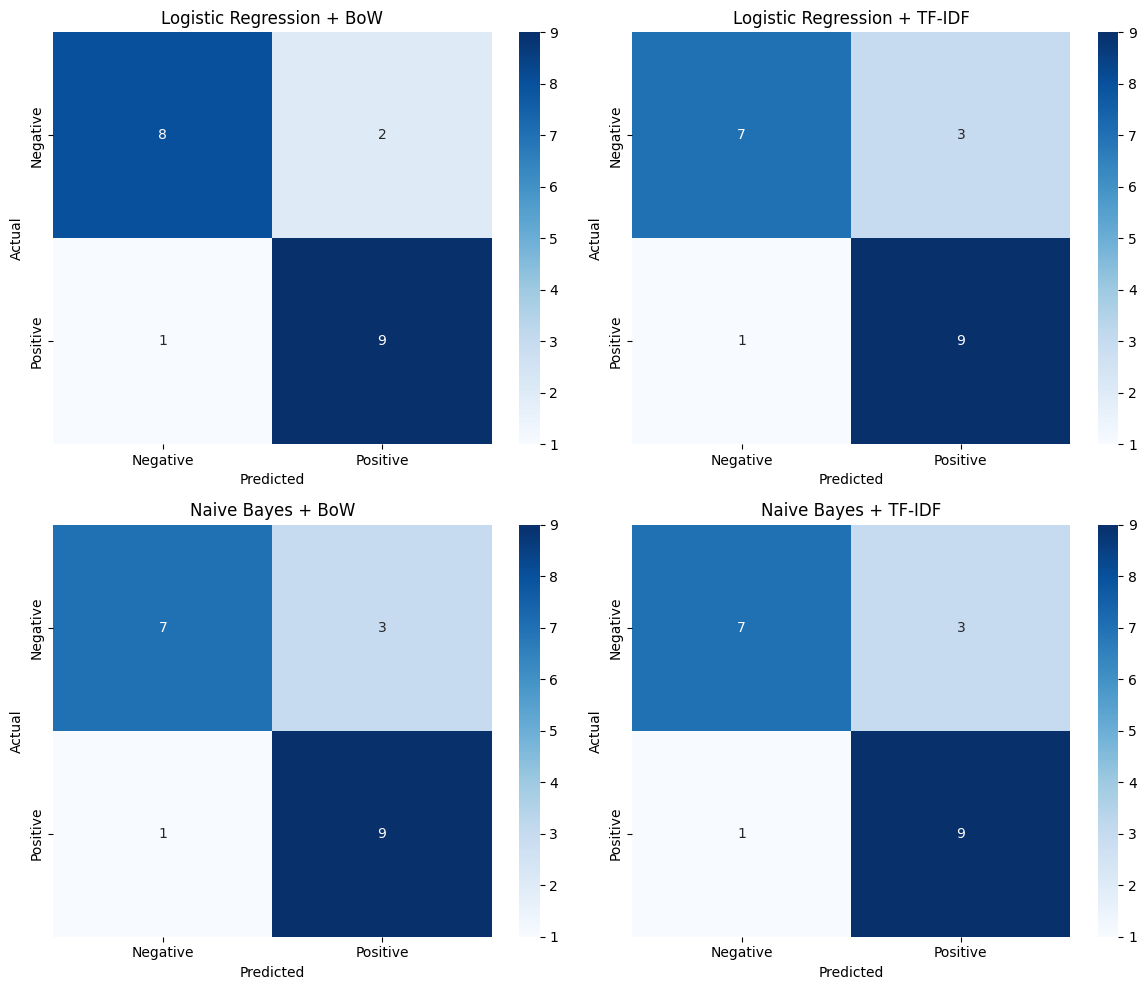


--------------------------------------------------------------------------------
FEATURE IMPORTANCE ANALYSIS
--------------------------------------------------------------------------------

Top 10 words indicating POSITIVE sentiment:
  purchase        : 0.9541
  great           : 0.7065
  exactly         : 0.5925
  excellent       : 0.5840
  best            : 0.5836
  wonderful       : 0.5669
  performance     : 0.5582
  outstanding     : 0.5472
  amazing         : 0.5330
  highly          : 0.5163

Top 10 words indicating NEGATIVE sentiment:
  disappointed    : -0.9491
  poor            : -0.9159
  terrible        : -0.6355
  waste           : -0.5989
  useless         : -0.5938
  complete        : -0.5381
  worst           : -0.4842
  money           : -0.4652
  horrible        : -0.4522
  broke           : -0.4275


In [15]:
# =============================================================================
# TASK 7: MINI USE CASE - SENTIMENT CLASSIFICATION
# =============================================================================

print("="*80)
print("SENTIMENT CLASSIFICATION: POSITIVE vs NEGATIVE REVIEWS")
print("="*80)

# Prepare data
X = df['processed_text']
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDataset Split:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples: {len(X_test)}")

# -----------------------------------------------------------------------------
# Model Training with Bag of Words
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("MODEL 1: USING BAG OF WORDS FEATURES")
print("-"*80)

# Vectorize with BoW
bow_vectorizer = CountVectorizer(max_features=500)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# Logistic Regression with BoW
lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

print("\nLogistic Regression + BoW:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr_bow):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_bow, target_names=['Negative', 'Positive']))

# Naive Bayes with BoW
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

print("\nNaive Bayes + BoW:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_nb_bow):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_bow, target_names=['Negative', 'Positive']))

# -----------------------------------------------------------------------------
# Model Training with TF-IDF
# -----------------------------------------------------------------------------

print("\n" + "-"*80)
print("MODEL 2: USING TF-IDF FEATURES")
print("-"*80)

# Vectorize with TF-IDF
tfidf_vectorizer_model = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf_vectorizer_model.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer_model.transform(X_test)

# Logistic Regression with TF-IDF
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

print("\nLogistic Regression + TF-IDF:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tfidf, target_names=['Negative', 'Positive']))

# Naive Bayes with TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("\nNaive Bayes + TF-IDF:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_nb_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_tfidf, target_names=['Negative', 'Positive']))

# -----------------------------------------------------------------------------
# Performance Comparison
# -----------------------------------------------------------------------------

print("\n" + "="*80)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*80)

results = {
    'Model': ['Logistic Regression', 'Logistic Regression', 'Naive Bayes', 'Naive Bayes'],
    'Features': ['Bag of Words', 'TF-IDF', 'Bag of Words', 'TF-IDF'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_bow),
        accuracy_score(y_test, y_pred_lr_tfidf),
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_nb_tfidf)
    ]
}

results_df = pd.DataFrame(results)
results_df['Accuracy'] = results_df['Accuracy'].apply(lambda x: f"{x:.4f}")
print("\n")
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    (y_pred_lr_bow, 'Logistic Regression + BoW'),
    (y_pred_lr_tfidf, 'Logistic Regression + TF-IDF'),
    (y_pred_nb_bow, 'Naive Bayes + BoW'),
    (y_pred_nb_tfidf, 'Naive Bayes + TF-IDF')
]

for ax, (y_pred, title) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Feature importance analysis
print("\n" + "-"*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("-"*80)

# Get feature names
feature_names = tfidf_vectorizer_model.get_feature_names_out()

# Logistic Regression coefficients (TF-IDF)
coef = lr_tfidf.coef_[0]
top_positive_idx = coef.argsort()[-10:][::-1]
top_negative_idx = coef.argsort()[:10]

print("\nTop 10 words indicating POSITIVE sentiment:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]:15} : {coef[idx]:.4f}")

print("\nTop 10 words indicating NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:15} : {coef[idx]:.4f}")
